In [ ]:
import mysql.connector
import pandas as pd

# Connection
cnx = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="********",
    database="coffee_shop_sales_db"
)

# Query
query = "SELECT * FROM coffee_sales"

# Load into DataFrame
df = pd.read_sql(query, cnx)

# Show data
print(df)

# Close connection
cnx.close()

C:\Users\DELL\AppData\Local\Temp\ipykernel_18712\2262902111.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)


        transaction_id transaction_date transaction_time  transaction_qty  \
0                    1       2023-01-01  0 days 07:06:11                2   
1                    2       2023-01-01  0 days 07:08:56                2   
2                    3       2023-01-01  0 days 07:14:04                2   
3                    4       2023-01-01  0 days 07:20:24                1   
4                    5       2023-01-01  0 days 07:22:41                2   
...                ...              ...              ...              ...   
112063          112321       2023-05-30  0 days 09:00:41                1   
112064          112322       2023-05-30  0 days 09:00:41                1   
112065          112323       2023-05-30  0 days 09:01:05                1   
112066          112324       2023-05-30  0 days 09:01:11                2   
112067          112325       2023-05-30  0 days 09:01:31                1   

        store_id   store_location  product_id  unit_price    product_catego

In [4]:
df

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,0 days 07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,0 days 07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,0 days 07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,0 days 07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,0 days 07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
112063,112321,2023-05-30,0 days 09:00:41,1,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
112064,112322,2023-05-30,0 days 09:00:41,1,5,Lower Manhattan,79,3.75,Bakery,Scone,Jumbo Savory Scone
112065,112323,2023-05-30,0 days 09:01:05,1,3,Astoria,28,2.00,Coffee,Gourmet brewed coffee,Columbian Medium Roast Sm
112066,112324,2023-05-30,0 days 09:01:11,2,3,Astoria,42,2.50,Tea,Brewed herbal tea,Lemon Grass Rg


In [12]:
df = df.copy()

# Convert Date & Time
df['transaction_date'] = pd.to_datetime(
    df['transaction_date'],
    dayfirst=True,
    errors='coerce'
)

df['transaction_time'] = pd.to_datetime(
    df['transaction_time'],
    format='%H:%M:%S',
    errors='coerce'
)

# Feature Engineering
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['month_name'] = df['transaction_date'].dt.strftime('%b')
df['day'] = df['transaction_date'].dt.day
df['day_of_week'] = df['transaction_date'].dt.day_name()
df['hour'] = df['transaction_time'].dt.hour

df['is_weekend'] = df['transaction_date'].dt.dayofweek.isin([5, 6])

df['day_type'] = df['is_weekend'].map({
    True: 'Weekend',
    False: 'Weekday'
})

# Sales Column
df['sales'] = df['unit_price'] * df['transaction_qty']

# Remove Null Dates
df.dropna(subset=['transaction_date'], inplace=True)

# Sort Orders
MONTH_ORDER = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

print("Clean Shape :", df.shape)
print("Date Range  :", df['transaction_date'].min(), "to", df['transaction_date'].max())

Clean Shape : (112068, 21)
Date Range  : 2023-01-01 00:00:00 to 2023-05-30 00:00:00


In [13]:
print("="*70)
print("               BUSINESS HEALTH SUMMARY")
print("="*70)

print(f"Total Revenue            : ${df['sales'].sum():,.2f}")
print(f"Total Orders             : {df['transaction_id'].count():,}")
print(f"Total Quantity Sold      : {df['transaction_qty'].sum():,}")
print(f"Average Order Value      : ${df['sales'].mean():.2f}")
print(f"Total Stores             : {df['store_location'].nunique()}")
print(f"Total Product Categories : {df['product_category'].nunique()}")
print(f"Total Products           : {df['product_type'].nunique()}")

               BUSINESS HEALTH SUMMARY
Total Revenue            : $524,304.27
Total Orders             : 112,068
Total Quantity Sold      : 161,066
Average Order Value      : $4.68
Total Stores             : 3
Total Product Categories : 9
Total Products           : 29


In [15]:
import matplotlib.pyplot as plt 

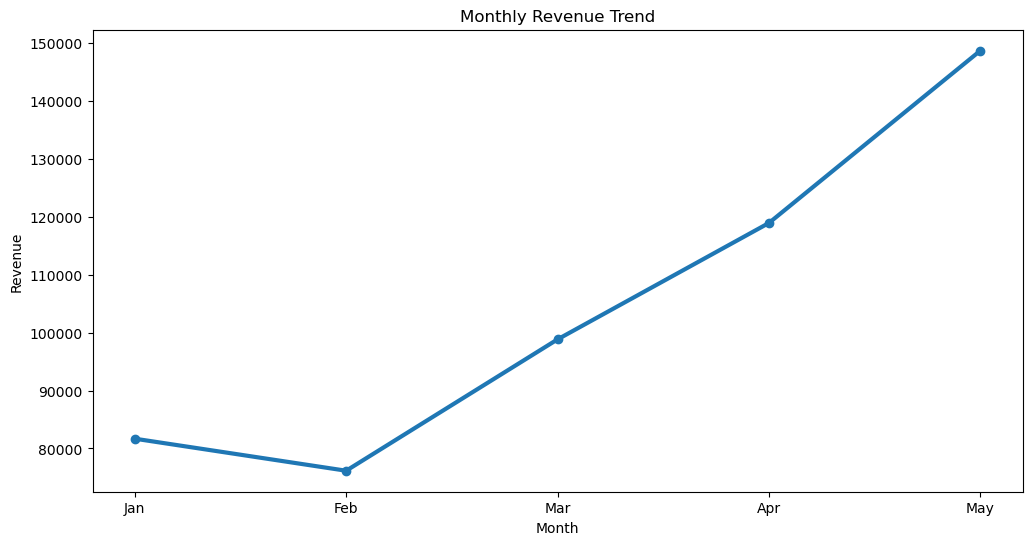

In [16]:
monthly_sales = (
    df.groupby('month_name')['sales']
    .sum()
    .reindex(MONTH_ORDER)
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=3
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

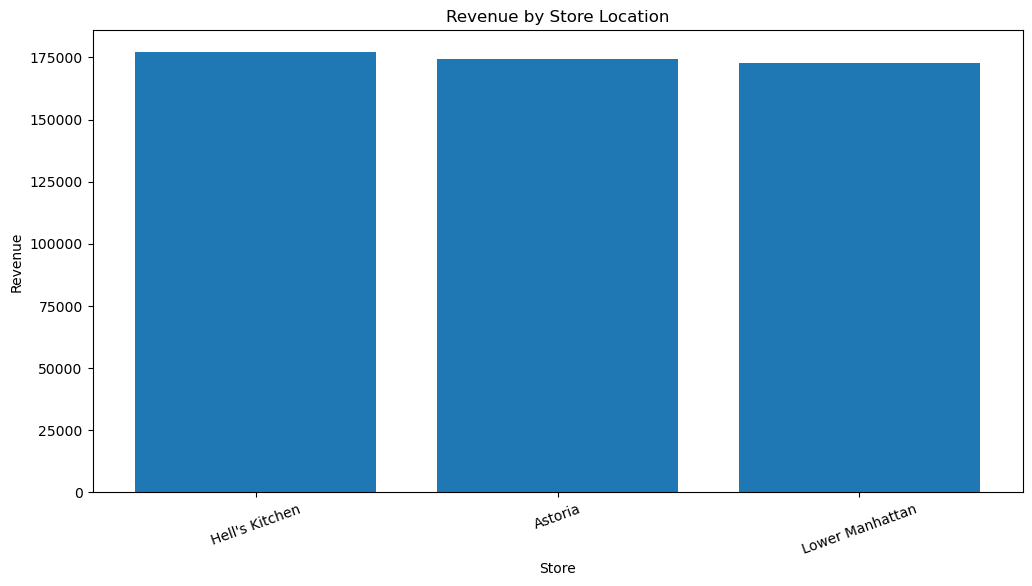

In [17]:
store_sales = (
    df.groupby('store_location')['sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(
    store_sales.index,
    store_sales.values
)

plt.title('Revenue by Store Location')
plt.xlabel('Store')
plt.ylabel('Revenue')

plt.xticks(rotation=20)

plt.show()

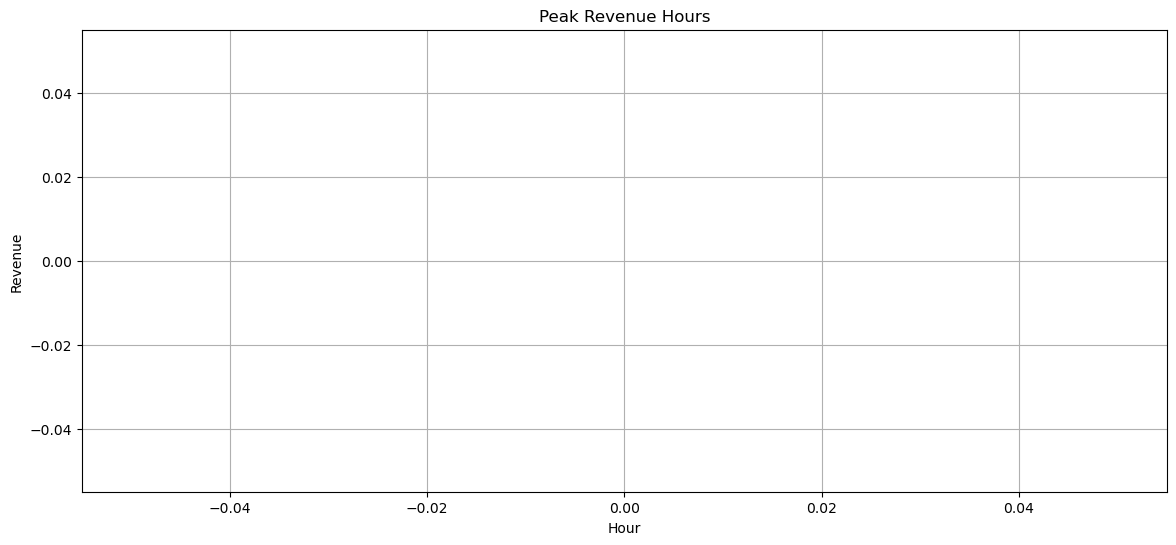

In [18]:
hourly_sales = (
    df.groupby('hour')['sales']
    .sum()
)

plt.figure(figsize=(14,6))

plt.plot(
    hourly_sales.index,
    hourly_sales.values,
    marker='o',
    linewidth=3
)

plt.title('Peak Revenue Hours')
plt.xlabel('Hour')
plt.ylabel('Revenue')

plt.grid(True)

plt.show()

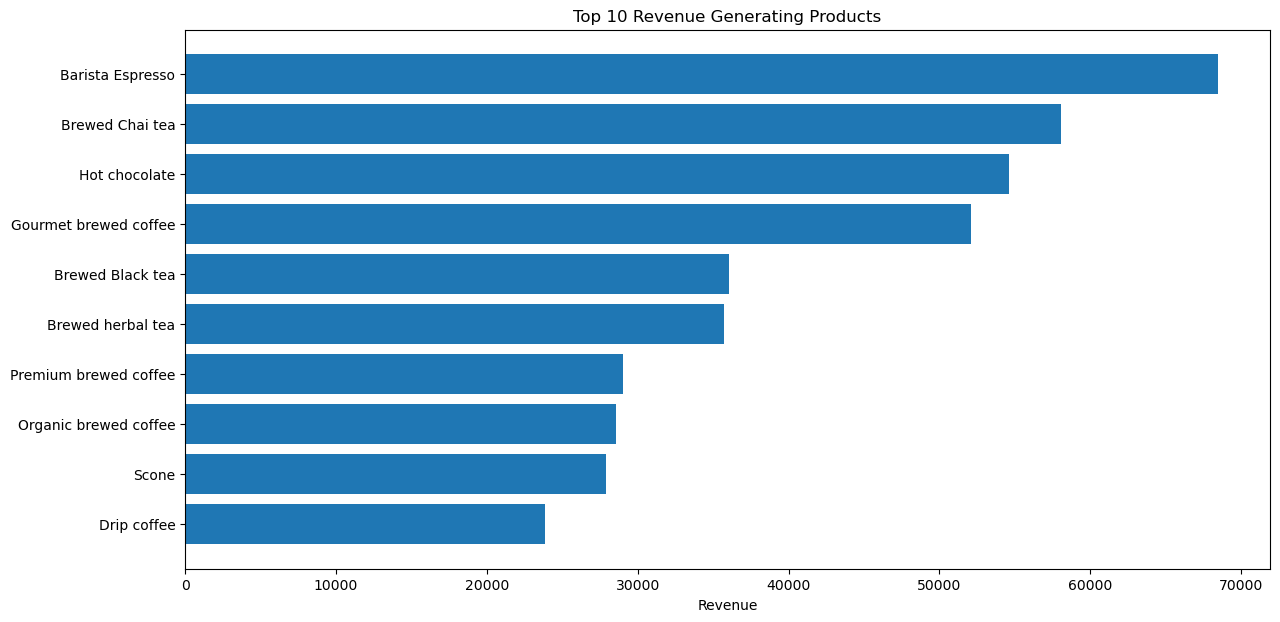

In [19]:
top_products = (
    df.groupby('product_type')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,7))

plt.barh(
    top_products.index[::-1],
    top_products.values[::-1]
)

plt.title('Top 10 Revenue Generating Products')
plt.xlabel('Revenue')

plt.show()

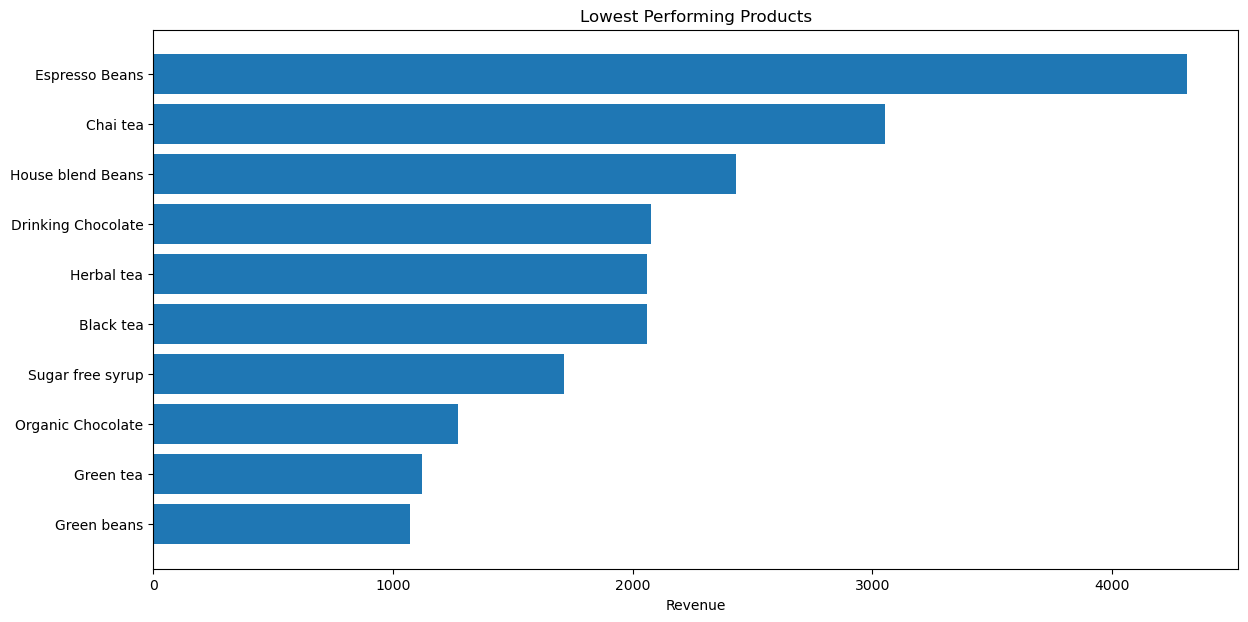

In [20]:
low_products = (
    df.groupby('product_type')['sales']
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(14,7))

plt.barh(
    low_products.index,
    low_products.values
)

plt.title('Lowest Performing Products')
plt.xlabel('Revenue')

plt.show()

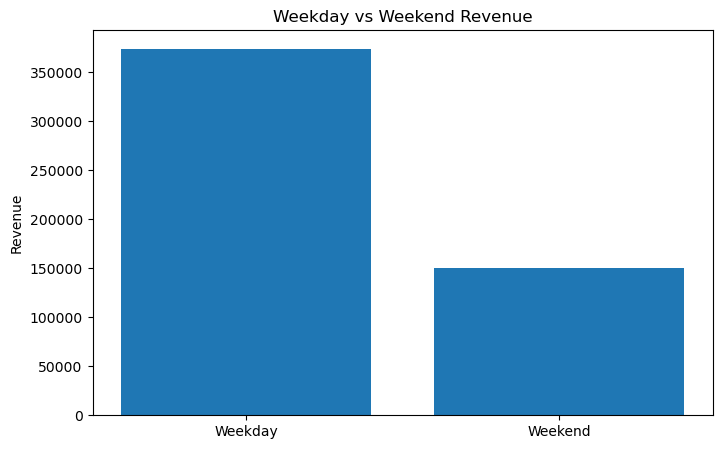

In [21]:
weekday_sales = (
    df.groupby('day_type')['sales']
    .sum()
)

plt.figure(figsize=(8,5))

plt.bar(
    weekday_sales.index,
    weekday_sales.values
)

plt.title('Weekday vs Weekend Revenue')
plt.ylabel('Revenue')

plt.show()

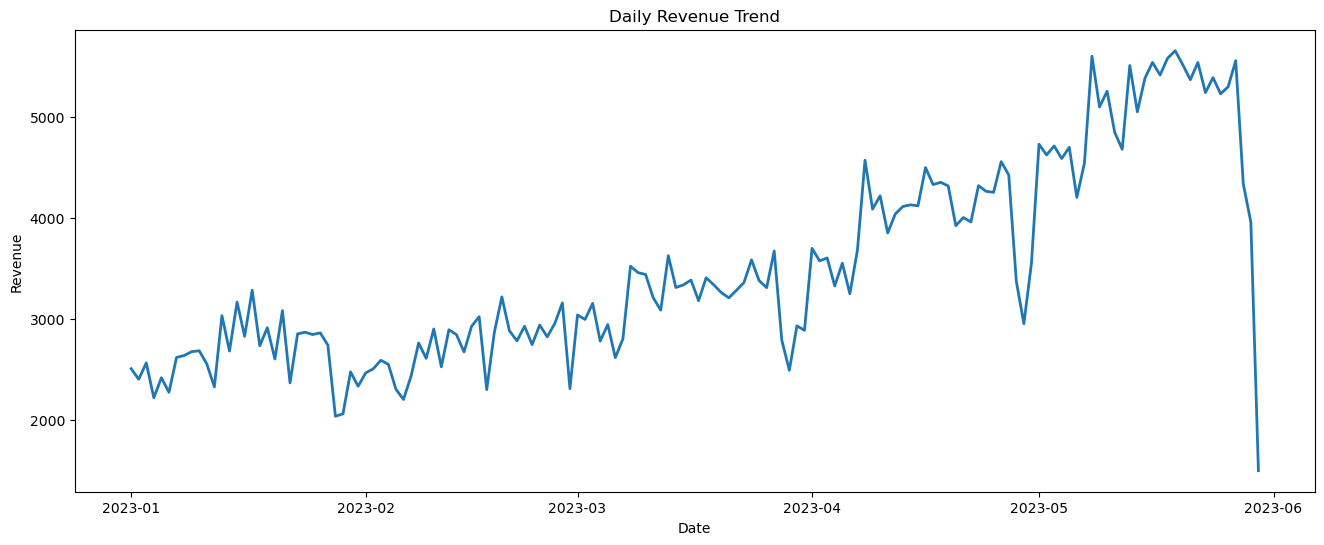

In [22]:
daily_sales = (
    df.groupby('transaction_date')['sales']
    .sum()
)

plt.figure(figsize=(16,6))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    linewidth=2
)

plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.show()

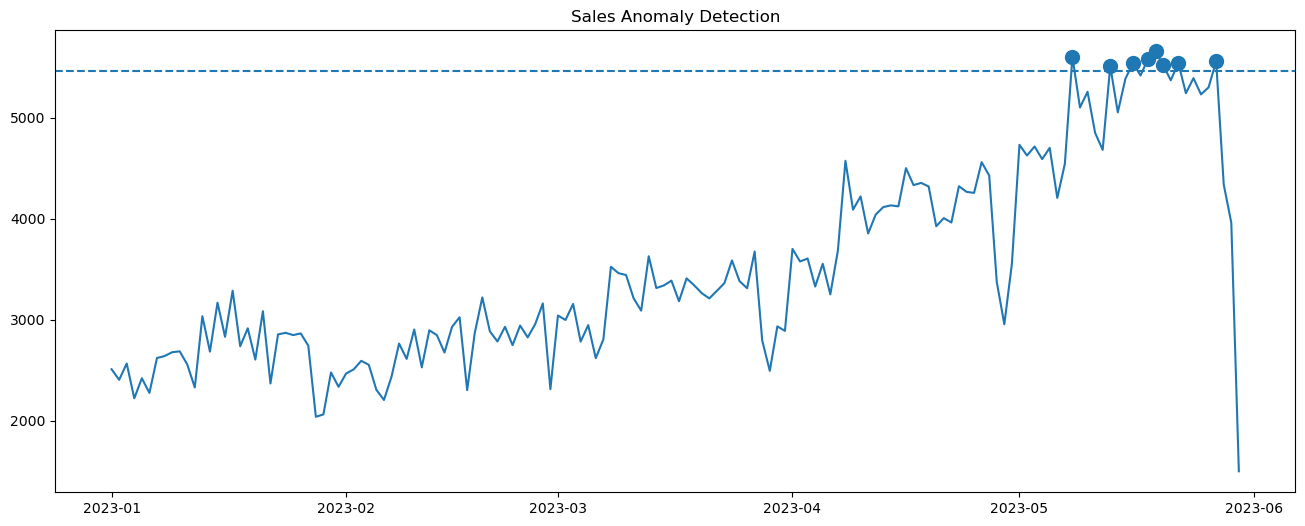

    transaction_date    sales
127       2023-05-08  5604.21
132       2023-05-13  5511.53
135       2023-05-16  5542.13
137       2023-05-18  5583.47
138       2023-05-19  5657.88
139       2023-05-20  5519.28
141       2023-05-22  5541.16
146       2023-05-27  5559.15


In [23]:
daily_sales_df = daily_sales.reset_index()

mean_sales = daily_sales_df['sales'].mean()
std_sales = daily_sales_df['sales'].std()

upper_limit = mean_sales + (2 * std_sales)

anomalies = daily_sales_df[
    daily_sales_df['sales'] > upper_limit
]

plt.figure(figsize=(16,6))

plt.plot(
    daily_sales_df['transaction_date'],
    daily_sales_df['sales']
)

plt.scatter(
    anomalies['transaction_date'],
    anomalies['sales'],
    s=100
)

plt.axhline(
    upper_limit,
    linestyle='--'
)

plt.title('Sales Anomaly Detection')

plt.show()

print(anomalies)

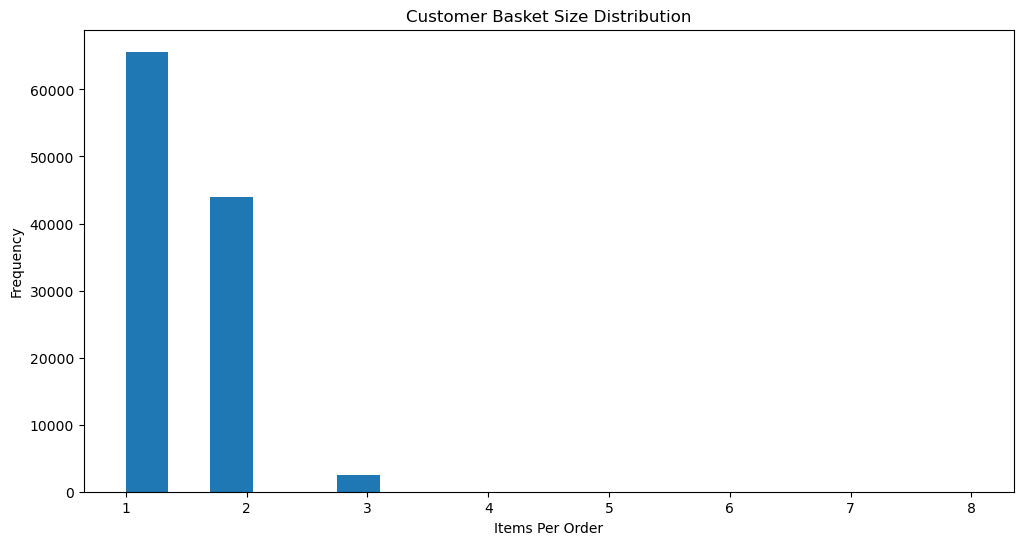

In [24]:
basket_size = (
    df.groupby('transaction_id')['transaction_qty']
    .sum()
)

plt.figure(figsize=(12,6))

plt.hist(
    basket_size,
    bins=20
)

plt.title('Customer Basket Size Distribution')
plt.xlabel('Items Per Order')
plt.ylabel('Frequency')

plt.show()

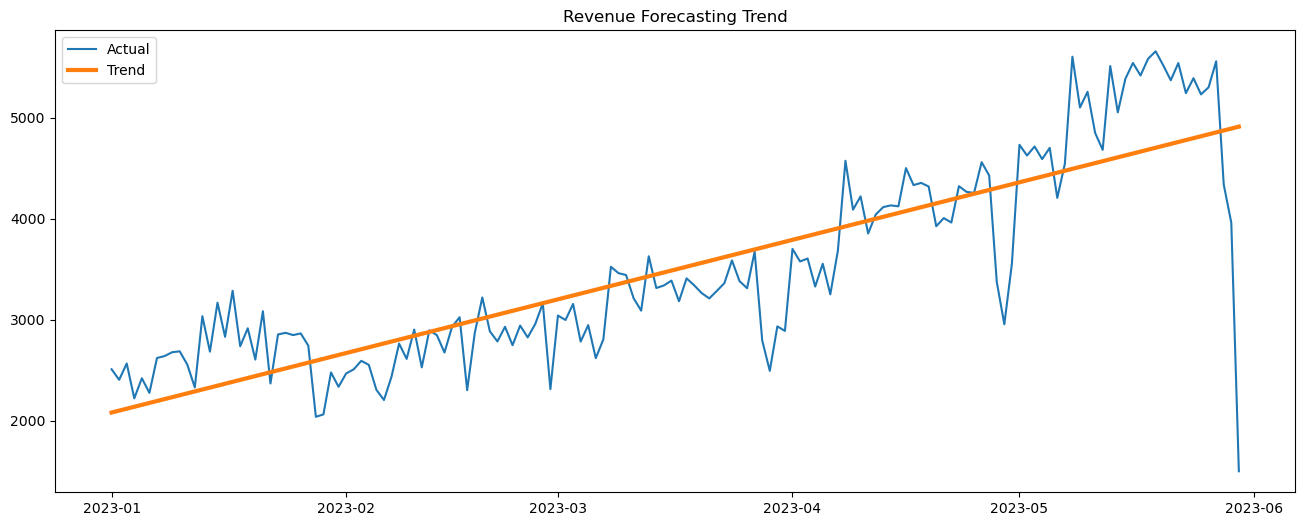

In [26]:
from sklearn.linear_model import LinearRegression
import numpy as np

forecast_df = daily_sales.reset_index()

forecast_df['day_number'] = np.arange(len(forecast_df))

X = forecast_df[['day_number']]
y = forecast_df['sales']

model = LinearRegression()
model.fit(X, y)

forecast_df['prediction'] = model.predict(X)

plt.figure(figsize=(16,6))

plt.plot(
    forecast_df['transaction_date'],
    forecast_df['sales'],
    label='Actual'
)

plt.plot(
    forecast_df['transaction_date'],
    forecast_df['prediction'],
    linewidth=3,
    label='Trend'
)

plt.legend()

plt.title('Revenue Forecasting Trend')

plt.show()

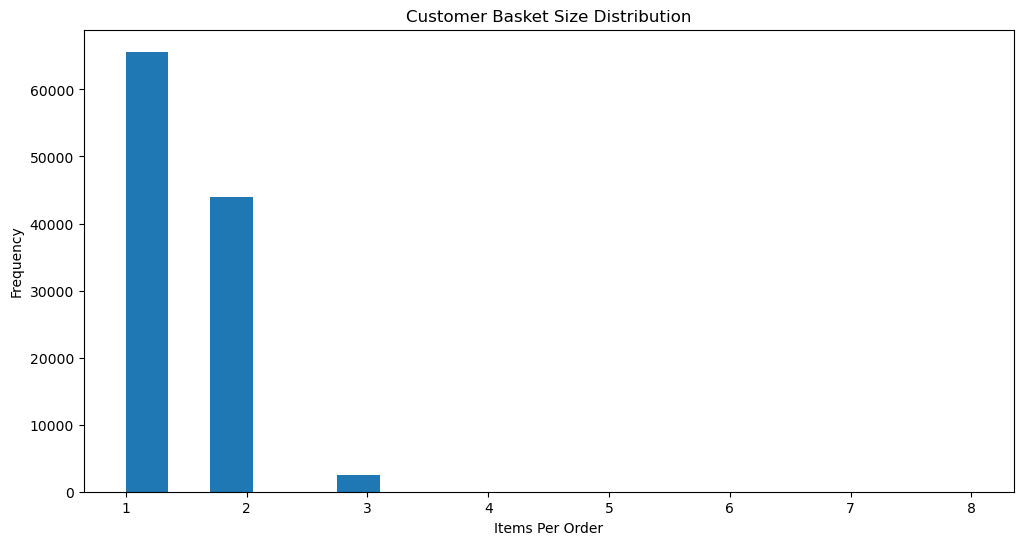

In [27]:
basket_size = (
    df.groupby('transaction_id')['transaction_qty']
    .sum()
)

plt.figure(figsize=(12,6))

plt.hist(
    basket_size,
    bins=20
)

plt.title('Customer Basket Size Distribution')
plt.xlabel('Items Per Order')
plt.ylabel('Frequency')

plt.show()

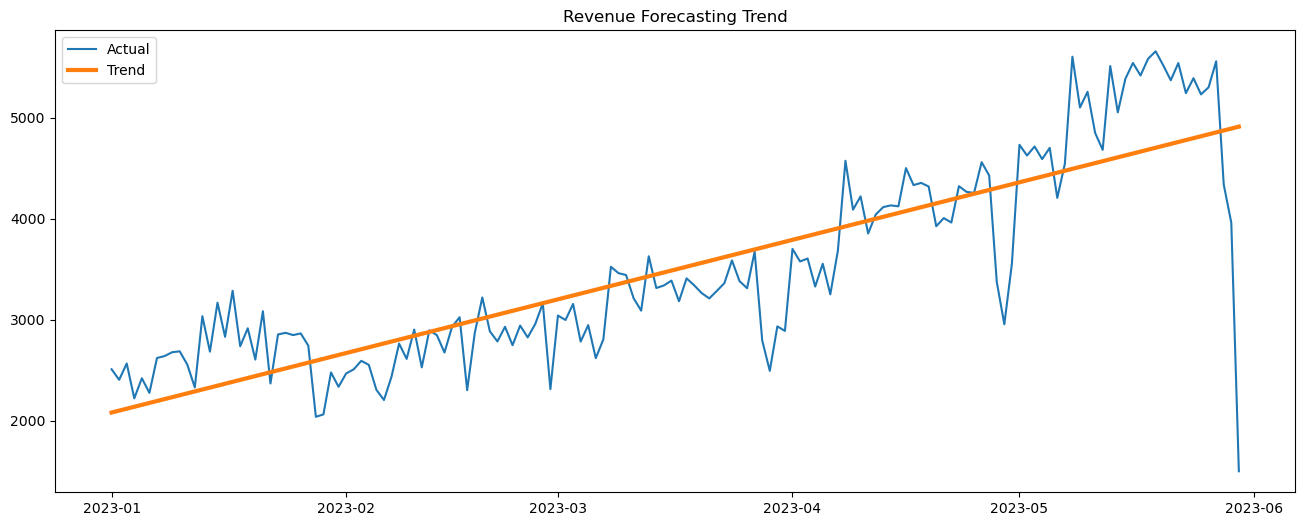

In [29]:
from sklearn.linear_model import LinearRegression

forecast_df = daily_sales.reset_index()

forecast_df['day_number'] = np.arange(len(forecast_df))

X = forecast_df[['day_number']]
y = forecast_df['sales']

model = LinearRegression()
model.fit(X, y)

forecast_df['prediction'] = model.predict(X)

plt.figure(figsize=(16,6))

plt.plot(
    forecast_df['transaction_date'],
    forecast_df['sales'],
    label='Actual'
)

plt.plot(
    forecast_df['transaction_date'],
    forecast_df['prediction'],
    linewidth=3,
    label='Trend'
)

plt.legend()

plt.title('Revenue Forecasting Trend')

plt.show()